# HW08-09 – PyTorch MLP: регуляризация и оптимизация обучения

В этом ноутбуке реализованы эксперименты E1-E4 (регуляризация MLP: Dropout, BatchNorm, EarlyStopping) и O1-O3 (диагностика learning rate, SGD+momentum + weight decay) для датасета EMNIST (split="balanced") из `torchvision`.


## 1. Импорты, seed и устройство


In [1]:
import json
from pathlib import Path
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms  # вернули torchvision
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## 2. Данные и DataLoader

- Загружаем EMNIST (split="balanced") из `torchvision.datasets`.
- Делаем разбиение train/val из train-части с фиксированным seed.
- Создаём `DataLoader` для train/val/test и делаем sanity-check.


In [ ]:
DATASET_NAME = "EMNIST_Balanced"

transform = transforms.ToTensor()

# Путь к данным (локальная папка рядом с репозиторием)
data_root = Path("data")
data_root.mkdir(exist_ok=True)

# EMNIST Balanced: split="balanced"
train_full = datasets.EMNIST(
    root=data_root,
    split="balanced",
    train=True,
    download=True,
    transform=transform,
)
test_ds = datasets.EMNIST(
    root=data_root,
    split="balanced",
    train=False,
    download=True,
    transform=transform,
)

NUM_CLASSES = len(train_full.classes)
print("num classes:", NUM_CLASSES)

val_frac = 0.2
n_train = int((1 - val_frac) * len(train_full))
n_val = len(train_full) - n_train
generator = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(train_full, [n_train, n_val], generator=generator)

BATCH_SIZE = 128

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# sanity-check батча
x_batch, y_batch = next(iter(train_loader))
print("train batch:", x_batch.shape, y_batch.shape)
print("value range:", float(x_batch.min()), float(x_batch.max()))

num classes: 47
train batch: torch.Size([128, 1, 28, 28]) torch.Size([128])
value range: 0.0 1.0


## 3. Модель MLP и вспомогательные функции обучения

- Определяем MLP с опциями Dropout и BatchNorm.
- Реализуем `train_one_epoch` и `evaluate` с корректным `train()/eval()` и `torch.no_grad()`.


In [3]:
class MLP(nn.Module):
    def __init__(
        self,
        input_size: int = 28 * 28,
        hidden_sizes=(256, 128),
        num_classes: int = NUM_CLASSES,
        use_dropout: bool = False,
        dropout_p: float = 0.3,
        use_batchnorm: bool = False,
    ):
        super().__init__()
        layers = []
        in_features = input_size
        for h in hidden_sizes:
            layers.append(nn.Linear(in_features, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if use_dropout:
                layers.append(nn.Dropout(dropout_p))
            in_features = h
        layers.append(nn.Linear(in_features, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)
        return self.net(x)


def accuracy_from_logits(logits: torch.Tensor, targets: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return running_loss / n_batches, running_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        running_loss += loss.item()
        running_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return running_loss / n_batches, running_acc / n_batches


## 4. Подготовка артефактов и функция `run_experiment`

- Создаём папку `artifacts/` и `artifacts/figures/` рядом с ноутбуком.
- Определяем функцию `run_experiment`, которая:
  - обучает модель,
  - логирует историю train/val,
  - реализует EarlyStopping (опционально),
  - дописывает строку в `artifacts/runs.csv`,
  - при необходимости сохраняет лучшую модель и конфиг.


In [4]:
artifacts_dir = Path("artifacts")
figures_dir = artifacts_dir / "figures"
artifacts_dir.mkdir(exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

RUNS_CSV = artifacts_dir / "runs.csv"
BEST_MODEL_PATH = artifacts_dir / "best_model.pt"
BEST_CONFIG_PATH = artifacts_dir / "best_config.json"


def run_experiment(
    experiment_id: str,
    hidden_sizes=(256, 128),
    use_dropout: bool = False,
    dropout_p: float = 0.3,
    use_batchnorm: bool = False,
    optimizer_name: str = "Adam",
    lr: float = 1e-3,
    momentum: float = 0.0,
    weight_decay: float = 0.0,
    max_epochs: int = 15,
    use_early_stopping: bool = False,
    patience: int = 5,
    dataset_name: str = DATASET_NAME,
    seed: int = SEED,
    save_best_model: bool = False,
):
    """Запускает один эксперимент обучения и логирует его в runs.csv."""
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = MLP(
        hidden_sizes=hidden_sizes,
        use_dropout=use_dropout,
        dropout_p=dropout_p,
        use_batchnorm=use_batchnorm,
        num_classes=NUM_CLASSES,
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "SGD":
        optimizer = torch.optim.SGD(
            model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay
        )
    else:
        raise ValueError(f"Unknown optimizer {optimizer_name}")

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }

    best_val_metric = -float("inf")
    best_val_loss = float("inf")
    best_state = None
    epochs_trained = 0
    epochs_no_improve = 0

    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        epochs_trained = epoch

        if val_acc > best_val_metric:
            best_val_metric = val_acc
            best_val_loss = val_loss
            best_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(
            f"[{experiment_id}] Epoch {epoch}/{max_epochs} "
            f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
            f"train_acc={train_acc:.4f} val_acc={val_acc:.4f}"
        )

        if use_early_stopping and epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    model_summary = (
        f"hidden={list(hidden_sizes)}, act=ReLU, "
        f"dropout={dropout_p if use_dropout else 0.0}, batchnorm={use_batchnorm}"
    )

    # лог в runs.csv
    import csv

    is_new_file = not RUNS_CSV.exists()
    with RUNS_CSV.open("a", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        if is_new_file:
            writer.writerow(
                [
                    "experiment_id",
                    "dataset",
                    "seed",
                    "model_summary",
                    "optimizer",
                    "lr",
                    "momentum",
                    "weight_decay",
                    "epochs_trained",
                    "best_val_accuracy",
                    "best_val_loss",
                ]
            )
        writer.writerow(
            [
                experiment_id,
                dataset_name,
                seed,
                model_summary,
                optimizer_name,
                lr,
                momentum,
                weight_decay,
                epochs_trained,
                best_val_metric,
                best_val_loss,
            ]
        )

    if save_best_model:
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        best_config = {
            "experiment_id": experiment_id,
            "dataset": dataset_name,
            "seed": seed,
            "model_summary": model_summary,
            "optimizer": optimizer_name,
            "lr": lr,
            "momentum": momentum,
            "weight_decay": weight_decay,
            "batch_size": BATCH_SIZE,
            "max_epochs": max_epochs,
            "early_stopping": {
                "enabled": use_early_stopping,
                "patience": patience,
                "monitor": "val_accuracy",
            },
            "best_val_accuracy": best_val_metric,
            "best_val_loss": best_val_loss,
        }
        BEST_CONFIG_PATH.write_text(
            json.dumps(best_config, indent=2, ensure_ascii=False), encoding="utf-8"
        )

    return model, history


## 5. Часть A (S08): регуляризация (E1-E4)

- **E1 (base)**: базовый MLP без Dropout и BatchNorm.
- **E2 (Dropout)**: как E1, но с Dropout.
- **E3 (BatchNorm)**: как E1, но с BatchNorm.
- **E4 (EarlyStopping)**: лучший из (E2/E3) + EarlyStopping, сохранение `best_model.pt` и `best_config.json`.


[E1] Epoch 1/20 train_loss=1.2857 val_loss=0.8580 train_acc=0.6366 val_acc=0.7427
[E1] Epoch 2/20 train_loss=0.7088 val_loss=0.6417 train_acc=0.7778 val_acc=0.8012
[E1] Epoch 3/20 train_loss=0.5736 val_loss=0.5953 train_acc=0.8143 val_acc=0.8074
[E1] Epoch 4/20 train_loss=0.5023 val_loss=0.5354 train_acc=0.8340 val_acc=0.8290
[E1] Epoch 5/20 train_loss=0.4559 val_loss=0.5244 train_acc=0.8446 val_acc=0.8292
[E1] Epoch 6/20 train_loss=0.4203 val_loss=0.5030 train_acc=0.8546 val_acc=0.8343
[E1] Epoch 7/20 train_loss=0.3940 val_loss=0.4911 train_acc=0.8614 val_acc=0.8389
[E1] Epoch 8/20 train_loss=0.3690 val_loss=0.4926 train_acc=0.8682 val_acc=0.8395
[E1] Epoch 9/20 train_loss=0.3476 val_loss=0.4865 train_acc=0.8746 val_acc=0.8427
[E1] Epoch 10/20 train_loss=0.3285 val_loss=0.4926 train_acc=0.8807 val_acc=0.8402
[E1] Epoch 11/20 train_loss=0.3109 val_loss=0.5019 train_acc=0.8847 val_acc=0.8402
[E1] Epoch 12/20 train_loss=0.2973 val_loss=0.5076 train_acc=0.8886 val_acc=0.8394
[E1] Epoch 13

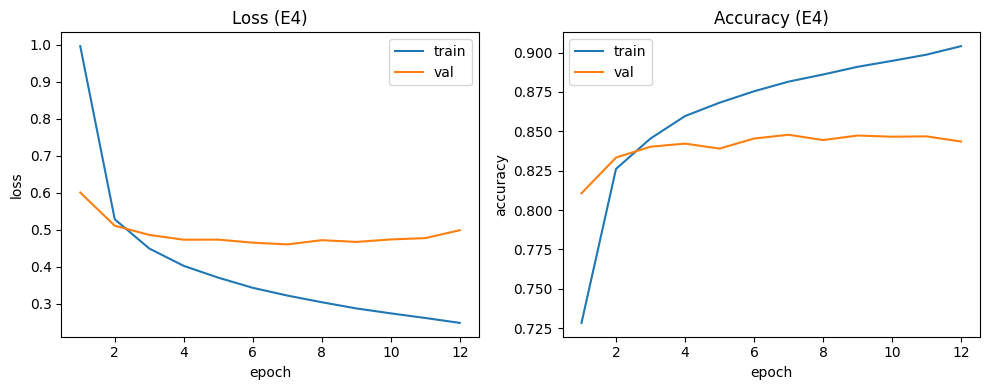

In [5]:
HIDDEN_SIZES = (256, 128)

# E1: базовый MLP без Dropout/BatchNorm
model_E1, hist_E1 = run_experiment(
    "E1",
    hidden_sizes=HIDDEN_SIZES,
    use_dropout=False,
    use_batchnorm=False,
    optimizer_name="Adam",
    lr=1e-3,
    weight_decay=0.0,
    max_epochs=20,
    use_early_stopping=False,
)

# E2: Dropout
model_E2, hist_E2 = run_experiment(
    "E2",
    hidden_sizes=HIDDEN_SIZES,
    use_dropout=True,
    dropout_p=0.3,
    use_batchnorm=False,
    optimizer_name="Adam",
    lr=1e-3,
    weight_decay=0.0,
    max_epochs=20,
    use_early_stopping=False,
)

# E3: BatchNorm
model_E3, hist_E3 = run_experiment(
    "E3",
    hidden_sizes=HIDDEN_SIZES,
    use_dropout=False,
    use_batchnorm=True,
    optimizer_name="Adam",
    lr=1e-3,
    weight_decay=0.0,
    max_epochs=20,
    use_early_stopping=False,
)

# Выбор лучшего конфига для E4 по лучшей val_accuracy среди E2/E3
best_hist_reg = hist_E2
best_id = "E2"
if max(hist_E3["val_acc"]) > max(hist_E2["val_acc"]):
    best_hist_reg = hist_E3
    best_id = "E3"

print(f"Лучший конфиг для E4 (по val_accuracy): {best_id}")

# E4: лучший конфиг + EarlyStopping, сохранение лучшей модели
model_E4, hist_E4 = run_experiment(
    "E4",
    hidden_sizes=HIDDEN_SIZES,
    use_dropout=(best_id == "E2"),
    dropout_p=0.3,
    use_batchnorm=(best_id == "E3"),
    optimizer_name="Adam",
    lr=1e-3,
    weight_decay=0.0,
    max_epochs=40,
    use_early_stopping=True,
    patience=5,
    save_best_model=True,
)

# Графики лучшего прогона (E4)
epochs_e4 = range(1, len(hist_E4["train_loss"]) + 1)
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_e4, hist_E4["train_loss"], label="train")
plt.plot(epochs_e4, hist_E4["val_loss"], label="val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Loss (E4)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_e4, hist_E4["train_acc"], label="train")
plt.plot(epochs_e4, hist_E4["val_acc"], label="val")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Accuracy (E4)")
plt.legend()

plt.tight_layout()
plt.savefig(figures_dir / "curves_best.png", dpi=150)
plt.show()


## 6. Часть B (S09): LR, оптимизаторы, weight decay (O1-O3)

- **O1**: Adam с **слишком большим** learning rate → деструктивное обучение.
- **O2**: Adam с **слишком маленьким** learning rate → почти нет прогресса.
- **O3**: SGD+momentum + weight decay на той же архитектуре, что и в E4.


[O1] Epoch 1/8 train_loss=1.0928 val_loss=0.8286 train_acc=0.6696 val_acc=0.7357
[O1] Epoch 2/8 train_loss=0.7825 val_loss=0.7036 train_acc=0.7496 val_acc=0.7802
[O1] Epoch 3/8 train_loss=0.7006 val_loss=0.7148 train_acc=0.7729 val_acc=0.7682
[O1] Epoch 4/8 train_loss=0.6600 val_loss=0.6788 train_acc=0.7832 val_acc=0.7940
[O1] Epoch 5/8 train_loss=0.6221 val_loss=0.6264 train_acc=0.7947 val_acc=0.8008
[O1] Epoch 6/8 train_loss=0.6088 val_loss=0.6266 train_acc=0.7978 val_acc=0.8029
[O1] Epoch 7/8 train_loss=0.5961 val_loss=0.6914 train_acc=0.8015 val_acc=0.7782
[O1] Epoch 8/8 train_loss=0.5777 val_loss=0.5973 train_acc=0.8072 val_acc=0.8100
[O2] Epoch 1/8 train_loss=3.4800 val_loss=3.1298 train_acc=0.1640 val_acc=0.3139
[O2] Epoch 2/8 train_loss=2.9190 val_loss=2.7267 train_acc=0.3990 val_acc=0.4680
[O2] Epoch 3/8 train_loss=2.5943 val_loss=2.4576 train_acc=0.5061 val_acc=0.5415
[O2] Epoch 4/8 train_loss=2.3507 val_loss=2.2334 train_acc=0.5625 val_acc=0.5880
[O2] Epoch 5/8 train_loss=2.

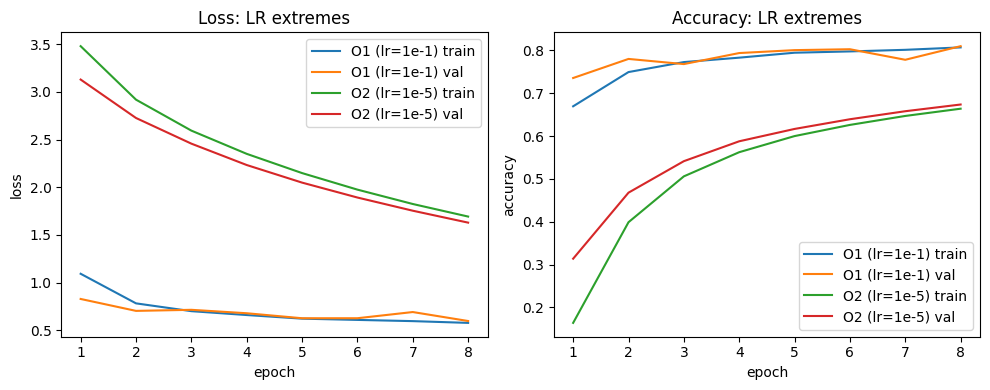

In [6]:
def run_short_lr_experiment(exp_id: str, lr: float, optimizer_name: str = "Adam", max_epochs: int = 8):
    model, history = run_experiment(
        exp_id,
        hidden_sizes=HIDDEN_SIZES,
        use_dropout=(best_id == "E2"),
        dropout_p=0.3,
        use_batchnorm=(best_id == "E3"),
        optimizer_name=optimizer_name,
        lr=lr,
        momentum=0.9 if optimizer_name == "SGD" else 0.0,
        weight_decay=0.0,
        max_epochs=max_epochs,
        use_early_stopping=False,
    )
    return history


# O1: LR слишком большой
hist_O1 = run_short_lr_experiment("O1", lr=1e-1, optimizer_name="Adam", max_epochs=8)

# O2: LR слишком маленький
hist_O2 = run_short_lr_experiment("O2", lr=1e-5, optimizer_name="Adam", max_epochs=8)

# O3: SGD+momentum + weight decay (на той же архитектуре, что и в E4)
model_O3, hist_O3 = run_experiment(
    "O3",
    hidden_sizes=HIDDEN_SIZES,
    use_dropout=(best_id == "E2"),
    dropout_p=0.3,
    use_batchnorm=(best_id == "E3"),
    optimizer_name="SGD",
    lr=5e-3,
    momentum=0.9,
    weight_decay=1e-4,
    max_epochs=15,
    use_early_stopping=False,
)


def plot_lr_extremes(hist1, hist2, label1: str, label2: str, filename: str):
    epochs1 = range(1, len(hist1["train_loss"]) + 1)
    epochs2 = range(1, len(hist2["train_loss"]) + 1)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs1, hist1["train_loss"], label=f"{label1} train")
    plt.plot(epochs1, hist1["val_loss"], label=f"{label1} val")
    plt.plot(epochs2, hist2["train_loss"], label=f"{label2} train")
    plt.plot(epochs2, hist2["val_loss"], label=f"{label2} val")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Loss: LR extremes")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs1, hist1["train_acc"], label=f"{label1} train")
    plt.plot(epochs1, hist1["val_acc"], label=f"{label1} val")
    plt.plot(epochs2, hist2["train_acc"], label=f"{label2} train")
    plt.plot(epochs2, hist2["val_acc"], label=f"{label2} val")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title("Accuracy: LR extremes")
    plt.legend()

    plt.tight_layout()
    plt.savefig(figures_dir / filename, dpi=150)
    plt.show()


plot_lr_extremes(hist_O1, hist_O2, "O1 (lr=1e-1)", "O2 (lr=1e-5)", "curves_lr_extremes.png")


## 7. Финальная оценка лучшей модели на test

- Загружаем `best_model.pt` из E4.
- Считаем accuracy на test (один раз).
- Дописываем `test_accuracy` в `best_config.json`.


In [7]:
# Финальная оценка лучшей модели (E4) на test
best_model = MLP(
    hidden_sizes=HIDDEN_SIZES,
    use_dropout=(best_id == "E2"),
    dropout_p=0.3,
    use_batchnorm=(best_id == "E3"),
    num_classes=NUM_CLASSES,
).to(device)
best_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))

criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)
print(f"Test loss: {test_loss:.4f}, test accuracy: {test_acc:.4f}")

# Дописываем test_accuracy в best_config.json
if BEST_CONFIG_PATH.exists():
    config = json.loads(BEST_CONFIG_PATH.read_text(encoding="utf-8"))
    config["test_accuracy"] = float(test_acc)
    BEST_CONFIG_PATH.write_text(
        json.dumps(config, indent=2, ensure_ascii=False), encoding="utf-8"
    )


Test loss: 0.5171, test accuracy: 0.8386
